# I. Formalisation du Problème d'Optimisation 

## 1. Contexte et Objectifs
Le défi de ce projet réside dans la **planification de la capacité** d'une infrastructure Cloud pour une application d'IA. 

**La problématique :** La demande ($\lambda$) est hautement variable.
- Si on sous-dimensionne : le système sature (Under-provisioning).
- Si on sur-dimensionne : on gaspille de l'argent (Over-provisioning).

**L'objectif :** Trouver une **configuration optimal** qui minimise le coût financier tout en garantissant que le système ne crash pas plus de $(1 - \alpha)\%$ du temps.

## 2. Paramètres du Système

### 2.1. Les Micro-services ($S$)
L'application est un pipeline de $N=4$ services. Pour chaque service $i \in \{1, 2, 3, 4\}$, nous avons des besoins fixes :
- $c_i^{cpu}$ : Consommation CPU (vCPU).
- $c_i^{ram}$ : Consommation RAM (GiB).
- $\mu_i$ : Capacité de traitement (requêtes/s par instance).

### 2.2. Le Catalogue Cloud ($VM$)
Nous disposons de $K$ types de machines virtuelles. Chaque type $k$ possède :
- $C_k^{cpu}$ et $C_k^{ram}$ : Sa capacité totale en ressources.
- $cost_k$ : Son coût horaire.
- $stock_k$ : Le nombre d'unités disponibles.



## 3. Variables de Décision

Pour résoudre le problème, nous devons fixer deux types de variables :
1. $r_i$ : Le nombre de répliques du micro-service $i$.
2. $x_k$ : Le nombre de machines virtuelles de type $k$ à louer.

## 4. Contraintes Mathématiques

### 4.1. Robustesse et Capacité de Traitement
La capacité globale du système, notée $\lambda_{\mathcal{C}}$, est limitée par le service ayant la plus petite capacité totale de traitement.

**La formule :**
$$\lambda_{\mathcal{C}} = \min_{i \in S} (r_i \cdot \mu_i)$$

Pour que le système soit **robuste**, cette capacité $\lambda_{\mathcal{C}}$ doit couvrir une proportion $\alpha$ du workload total :
$$\mathbb{P}\big(\lambda(t) \le \lambda_{\mathcal{C}}\big) \ge \alpha$$
*Note : Si $\alpha = 0.95$, cela signifie que la configuration choisie doit pouvoir traiter le trafic dans 95% des cas répertoriés dans le fichier workload.*

### 4.2. Adéquation Ressources / Infrastructure
**Logique :** Toutes les instances déployées ($r_i$) doivent tenir physiquement dans l'espace CPU et RAM offert par les VMs louées ($x_k$).

* **Somme du CPU requis $\le$ Somme du CPU loué :**
    $$\sum_{i \in S} r_i \cdot c_i^{cpu} \le \sum_{k \in VM} x_k \cdot C_k^{cpu}$$

* **Somme de la RAM requise $\le$ Somme de la RAM louée :**
    $$\sum_{i \in S} r_i \cdot c_i^{ram} \le \sum_{k \in VM} x_k \cdot C_k^{ram}$$

### 4.3. Limite des Stocks
**Logique :** On ne peut pas louer plus de machines que le fournisseur n'en possède.
$$\forall k \in VM, \quad x_k \le stock_k$$


## 5. Fonction Objectif

L'objectif final est économique . On cherche à minimiser la facture totale horaire en jouant sur le mix de machines choisies :

$$\min \sum_{k \in VM} x_k \cdot cost_k$$


## 6. Synthèse de la démarche de résolution

1. Niveaux 1 Cas statique
2. Niveaux 2 Cas dynamique
3. Niveaux 3 Estiamtion 

# II Niveaux 1 Cas statique

### 1. Visualisation des données Workloads
**Objectifs** : Extraire les données du CSV Workloads et faire un visualisation des données afin de trouver la valeurs maximale des requets


In [3]:
import pandas as pd

class DataCollector:

    def __init__(self):
        pass

    def collect(self, path: str) -> pd.DataFrame:
        # Lecture du fichier Excel avec openpyxl
        df = pd.read_excel(path, engine="openpyxl")
        df.columns = [col.strip().lower() for col in df.columns]
        required_columns = {"time", "input_rate"}

        if not required_columns.issubset(df.columns):
            raise ValueError(
                f"Colonnes requises manquantes. Trouvées: {df.columns}"
            )

        df = df[["time", "input_rate"]].rename(
            columns={
                "time": "time",
                "input_rate": "input_rates"
            }
        )

        return df


   time  input_rates
0     0          340
1     1          469
2     2          541
3     3          378
4     4          396


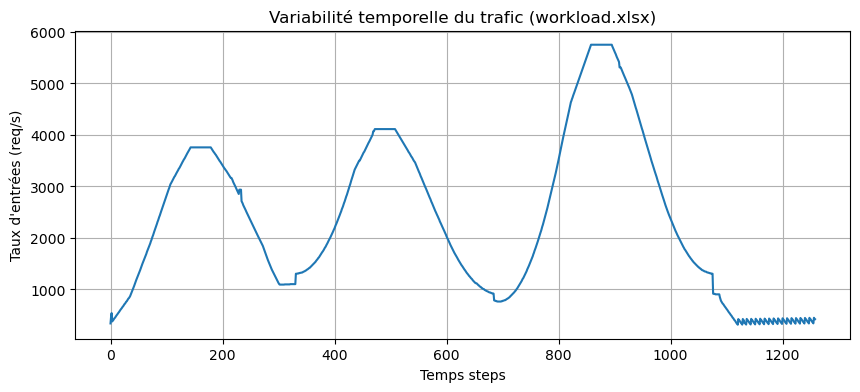

**PIC DE TRAFIC MAXIMAL Ymax** : 5751.00 req/s
 **Instant du pic ** : 858


In [41]:
import os
import matplotlib.pyplot as plt
import numpy as np

# Si tu es dans un notebook, tu peux définir la racine comme le dossier courant
ROOT_DIR = os.getcwd()

file_path = os.path.join(
    ROOT_DIR,
    "data_sample",
    "input",
    "Data",
    "Workload.xlsx"
)

collector = DataCollector()
data = collector.collect(file_path)
print(data.head())  # pour vérifier les colonnes

# Adapte ces noms aux colonnes exactes de Workload.xlsx
x = data["time"].values          # par ex. "time" si c'est le nom
y = data["input_rates"].values   # par ex. "input_rates" si c'est le nom

plt.figure(figsize=(10, 4))
plt.plot(x, y)
plt.xlabel("Temps steps")
plt.ylabel("Taux d'entrées (req/s)")
plt.title("Variabilité temporelle du trafic (workload.xlsx)")
plt.grid(True)
plt.show()

print(f"**PIC DE TRAFIC MAXIMAL Ymax** : {np.max(y):.2f} req/s")
print(f" **Instant du pic ** : {x[np.argmax(y)]}")


Nous connaissons maintenant la valeurs Max aux niveaux du pic de fréquentation égale à 5751 req/s à la steps 858.

Notre objectifs est de déterminer le parcs de VM optimal pour la configuration maximal.
Pour cela nous avons besoin de connaître la consomation unitaire d'une application afin de déterminer le besoins global pour ce maximum.

In [5]:
import math

services_config = {
    "Service 1 Pre-processing": {"cpu": 1, "ram": 0.5, "mu": 1416},  # mu = capacité de traitement (req/s)
    "Service 2 Model Worker": {"cpu": 4, "ram": 2.5, "mu": 696},
    "Service 3 Parameter Server": {"cpu": 2, "ram": 1.5, "mu": 1005},
    "Service 4 Evaluator": {"cpu": 1, "ram": 1, "mu": 1259}
}

cpu_unitaire = sum(specs["cpu"] for specs in services_config.values())
ram_unitaire = sum(specs["ram"] for specs in services_config.values())

print(f"--- CONSOMMATION POUR 1 APPLICATION (UNITAIRE) ---")
print(f"Total CPU : {cpu_unitaire} vCPUs")
print(f"Total RAM : {ram_unitaire} GiB")

# --- CALCUL DE LA CAPACITÉ MAX DU PIPELINE (SANS RÉPLICATION) ---
# La capacité d'un pipeline sans répliques est limitée par le maillon le plus lent
mu_unitaire = min(specs["mu"] for specs in services_config.values())

print(f"Capacité max d'un pipeline simple : {mu_unitaire} req/s")

--- CONSOMMATION POUR 1 APPLICATION (UNITAIRE) ---
Total CPU : 8 vCPUs
Total RAM : 5.5 GiB
Capacité max d'un pipeline simple : 696 req/s


On connait maintenant la consomation d'une application. 
<br>
Calculons la consomation CPU et de la RAM afin d'atteindre la capacité maximal 5751.0 req/s


In [6]:
import math

services_config = {
    "Service 1 Pre-processing": {"cpu": 1, "ram": 0.5, "mu": 1416},
    "Service 2 Model Worker": {"cpu": 4, "ram": 2.5, "mu": 696},
    "Service 3 Parameter Server": {"cpu": 2, "ram": 1.5, "mu": 1005},
    "Service 4 Evaluator": {"cpu": 1, "ram": 1, "mu": 1259}
}

lambda_max = 5751.0

total_cpu_global = 0
total_ram_global = 0
capacites_services = []

print(f"--- DIMENSIONNEMENT POUR LE PIC ({lambda_max} req/s) ---")
print(f"{'Service':<28} | {'Répliques':<10} | {'CPU Total':<8} | {'RAM Total':<8} | {'Capacité Réelle':<15}")
print("-" * 65)

for name, specs in services_config.items():
    ri = math.ceil(lambda_max / specs["mu"])
    
    # Capacité réelle de cet étage du pipeline
    capacite_reelle_service = ri * specs["mu"]
    capacites_services.append(capacite_reelle_service)
    
    cpu_service = ri * specs["cpu"]
    ram_service = ri * specs["ram"]
    
    total_cpu_global += cpu_service
    total_ram_global += ram_service
    
    print(f"{name:<28} | {ri:<10} | {cpu_service :<8}| {ram_service:<8}|{capacite_reelle_service:<15.2f} req/s")

disponibilite_totale = min(capacites_services)
marge = disponibilite_totale - lambda_max

print("-" * 60)
print(f"CAPACITÉ TOTALE Réel       : { disponibilite_totale:.2f} req/s")
print(f"MARGE Previsions/Réels     : {marge:.2f} req/s")
print(f"CONSOMMATION CPU           : {total_cpu_global} vCPUs")
print(f"CONSOMMATION RAM           : {total_ram_global} GiB")

--- DIMENSIONNEMENT POUR LE PIC (5751.0 req/s) ---
Service                      | Répliques  | CPU Total | RAM Total | Capacité Réelle
-----------------------------------------------------------------
Service 1 Pre-processing     | 5          | 5       | 2.5     |7080.00         req/s
Service 2 Model Worker       | 9          | 36      | 22.5    |6264.00         req/s
Service 3 Parameter Server   | 6          | 12      | 9.0     |6030.00         req/s
Service 4 Evaluator          | 5          | 5       | 5       |6295.00         req/s
------------------------------------------------------------
CAPACITÉ TOTALE Réel       : 6030.00 req/s
MARGE Previsions/Réels     : 279.00 req/s
CONSOMMATION CPU           : 58 vCPUs
CONSOMMATION RAM           : 39.0 GiB


Nous connaissons maintenant la configuration total necessaire afin d'assurer le pic de trafic.
On constate que le services 2 Model Worker necessite un nombre de répliquation plus importants. ce qui augmente le besoins en CPU et donc en machines.
Le besoins s'explique par l'importance du services. En effet, le service Model Worker est le service qui fait tourner les algorithmes d'IA. Ce service justifie donc le besoins plus important de capacité de calculs donc de CPU et de mémoire vives. 

Avec toutes ces informations obtenus en amonts, ils nous restent de trouver la meilleur configuration possible.
Pour cela nous devons implementer un algorithme de recherche qui compare notre configuration actuel avec le catalogue des VM et cherches à minimiser le coups tout en respectant la quantité disponible


Pour répondre à ce problème complexe d'allocation de ressources, nous avons sélectionné deux approches. 

La première repose sur une stratégie gloutonne (Greedy Search) : elle permet d'obtenir une solution immédiate et cohérente en ordonnant les besoins par criticité pour les placer dans les ressources disponibles les plus adaptées. C'est une méthode robuste qui garantit une base de référence (baseline) performante. 

La seconde approche utilise un algorithme génétique, une méthode mheuristique inspirée de l'évolution naturelle. Contrairement à l'approche gloutonne qui prend des décisions locales définitives, l'algorithme génétique explore un espace de solutions beaucoup plus vaste par croisement et mutation. 
Ce choix est justifié par la nature du problème : là où une règle logique simple peut rester bloquée, l'intelligence du modèle génétique permet d'optimiser le coût global en trouvant des combinaisons de machines virtuelles hétérogènes plus économes, minimisant ainsi le gaspillage de CPU et de RAM.

In [42]:
def collect_vms(path):
    # Lecture en sautant la ligne de titre si nécessaire 
    df = pd.read_excel(path, engine="openpyxl", header=1)
    df.columns = [col.strip() for col in df.columns]
    return df.to_dict(orient='records')

ROOT_DIR = os.getcwd()
vm_file_path = os.path.join(ROOT_DIR, "data_sample", "input", "Data", "VM_Catalogue.xlsx")

vm_catalogue = collect_vms(vm_file_path)

# --- GÉNÉRATION DES RÉPLIQUES (Besoin Global) ---
services_specs = {
    "S1 Pre-processing": {"cpu": 1, "ram": 0.5, "mu": 1416},
    "S2 Model Worker": {"cpu": 4, "ram": 2.5, "mu": 696},
    "S3 Parameter Server": {"cpu": 2, "ram": 1.5, "mu": 1005},
    "S4 Evaluator": {"cpu": 1, "ram": 1, "mu": 1259}
}

lambda_max = 5751.0
all_replicas = []
for name, specs in services_specs.items():
    nb_ri = math.ceil(lambda_max / specs["mu"])
    for _ in range(nb_ri):
        all_replicas.append({"name": name, "cpu": specs["cpu"], "ram": specs["ram"]})

In [43]:
def solve_greedy_detailed(replicas, catalogue):
    sorted_reps = sorted(replicas, key=lambda x: x['cpu'], reverse=True)
    opened_vms = []

    for rep in sorted_reps:
        placed = False
        for vm in opened_vms:
            if vm['cpu_left'] >= rep['cpu'] and vm['ram_left'] >= rep['ram']:
                vm['cpu_left'] -= rep['cpu']
                vm['ram_left'] -= rep['ram']
                vm['items'].append(rep['name'])
                placed = True
                break
        
        if not placed:
            best_choice = next(v for v in catalogue if v['CPU'] >= rep['cpu'] and v['RAM'] >= rep['ram'])
            opened_vms.append({
                'Type': best_choice['Type'],
                'cpu_left': best_choice['CPU'] - rep['cpu'],
                'ram_left': best_choice['RAM'] - rep['ram'],
                'Cost': best_choice['Cost'],
                'items': [rep['name']]
            })
    
    return opened_vms
    
ap_totale_systeme = min(capacites_services)

print("\nDÉTAILS DE L'INFRASTRUCTURE ")
df_res = pd.DataFrame(results_greedy)
summary = df_res.groupby('Type').agg({'Type': 'count', 'Cost': 'first'})
summary.columns = ['Quantité', 'Prix Unitaire ($/h)']
summary['Total Section'] = summary['Quantité'] * summary['Prix Unitaire ($/h)']
print(summary)

print("-" * 55)
print(f"CAPACITÉ TOTALE DU SYSTÈME : {cap_totale_systeme:.2f} req/s")
print(f"OBJECTIF                   : {lambda_max:.2f} req/s")
print(f"MARGE DE SÉCURITÉ          : {cap_totale_systeme - lambda_max:.2f} req/s")
print(f"COÛT TOTAL HORAIRE         : {df_res['Cost'].sum():.4f} $/h")


DÉTAILS DE L'INFRASTRUCTURE 
      Quantité  Prix Unitaire ($/h)  Total Section
Type                                              
T00         10               0.1914         1.9140
T01          6               0.2104         1.2624
T04          9               0.3064         2.7576
-------------------------------------------------------
CAPACITÉ TOTALE DU SYSTÈME : 6030.00 req/s
OBJECTIF                   : 5751.00 req/s
MARGE DE SÉCURITÉ          : 279.00 req/s
COÛT TOTAL HORAIRE         : 5.9340 $/h


In [58]:
import random
class GeneticOptimizer:
    def __init__(self, replicas, catalogue, pop_size=30, gens=300):
        self.replicas = replicas
        self.catalogue = catalogue
        self.pop_size = pop_size
        self.gens = gens

    def fitness(self, individual):
        vm_map = {}
        for i, vm_id in enumerate(individual):
            if vm_id not in vm_map: vm_map[vm_id] = {'c': 0, 'r': 0}
            vm_map[vm_id]['c'] += self.replicas[i]['cpu']
            vm_map[vm_id]['r'] += self.replicas[i]['ram']
        
        cost = 0
        for usage in vm_map.values():
            # Trouver la VM la moins chère qui supporte ce groupe de répliques
            options = [v for v in self.catalogue if v['CPU'] >= usage['c'] and v['RAM'] >= usage['r']]
            if not options: return 0 # Solution invalide
            cost += min(o['Cost'] for o in options)
        return 1 / cost

    def run(self):
        # Initialisation : chaque réplique va dans une "boite" aléatoire
        pop = [[random.randint(0, 15) for _ in range(len(self.replicas))] for _ in range(self.pop_size)]
        
        for _ in range(self.gens):
            pop = sorted(pop, key=self.fitness, reverse=True)
            # Elitisme + Crossover
            next_gen = pop[:5]
            while len(next_gen) < self.pop_size:
                p1, p2 = random.sample(pop[:10], 2)
                cut = random.randint(1, len(self.replicas)-1)
                child = p1[:cut] + p2[cut:]
                # Mutation
                if random.random() < 0.2:
                    child[random.randint(0, len(child)-1)] = random.randint(0, 15)
                next_gen.append(child)
            pop = next_gen
        
        return pop[0]

ga = GeneticOptimizer(all_replicas, vm_catalogue)
best_config = ga.run()

print("RÉSULTATS ALGO GÉNÉTIQUE")

final_vms = {}
placed_services_counts = {}

for i, vm_id in enumerate(best_config):
    replica = all_replicas[i]
    service_name = replica['name']
    
    placed_services_counts[service_name] = placed_services_counts.get(service_name, 0) + 1
    
    if vm_id not in final_vms: 
        final_vms[vm_id] = {'c': 0, 'r': 0, 'items': []}
    final_vms[vm_id]['c'] += replica['cpu']
    final_vms[vm_id]['r'] += replica['ram']
    final_vms[vm_id]['items'].append(service_name)


capacites_services = []
print(f"{'Service':<25} | {'Répliques':<10} | {'Capacité (req/s)':<15}")
print("-" * 55)

for name, specs in services_specs.items():
    nb_reps = placed_services_counts.get(name, 0)
    cap_service = nb_reps * specs['mu']
    capacites_services.append(cap_service)
    print(f"{name:<25} | {nb_reps:<10} | {cap_service:<15.2f}")

cap_totale_systeme = min(capacites_services)

total_cost_ga = 0
print("\n--- DÉTAIL DES MACHINES VIRTUELLES ---")
for vm_id, v_usage in final_vms.items():
    options = [v for v in vm_catalogue if v['CPU'] >= v_usage['c'] and v['RAM'] >= v_usage['r']]
    if options:
        best_vm = min(options, key=lambda x: x['Cost'])
        total_cost_ga += best_vm['Cost']
        print(f"VM ID {vm_id:02d}: Type {best_vm['Type']} | Utilisation: {v_usage['c']} vCPU, {v_usage['r']} RAM")

print("-" * 55)
print(f"CAPACITÉ TOTALE DU SYSTÈME : {cap_totale_systeme:.2f} req/s")
print(f"OBJECTIF                   : {lambda_max:.2f} req/s")
print(f"MARGE DE SÉCURITÉ          : {cap_totale_systeme - lambda_max:.2f} req/s")
print(f"COÛT TOTAL HORAIRE         : {total_cost_ga:.4f} $/h")

RÉSULTATS ALGO GÉNÉTIQUE
Service                   | Répliques  | Capacité (req/s)
-------------------------------------------------------
S1 Pre-processing         | 5          | 7080.00        
S2 Model Worker           | 9          | 6264.00        
S3 Parameter Server       | 6          | 6030.00        
S4 Evaluator              | 5          | 6295.00        

--- DÉTAIL DES MACHINES VIRTUELLES ---
VM ID 13: Type T07 | Utilisation: 8 vCPU, 5.0 RAM
VM ID 06: Type T01 | Utilisation: 2 vCPU, 1.0 RAM
VM ID 00: Type T07 | Utilisation: 8 vCPU, 5.5 RAM
VM ID 11: Type T07 | Utilisation: 8 vCPU, 5.5 RAM
VM ID 02: Type T07 | Utilisation: 8 vCPU, 5.0 RAM
VM ID 09: Type T10 | Utilisation: 16 vCPU, 11.0 RAM
VM ID 12: Type T07 | Utilisation: 8 vCPU, 6.0 RAM
-------------------------------------------------------
CAPACITÉ TOTALE DU SYSTÈME : 6030.00 req/s
OBJECTIF                   : 5751.00 req/s
MARGE DE SÉCURITÉ          : 279.00 req/s
COÛT TOTAL HORAIRE         : 3.5848 $/h


## Etude de Scabilité

Dans le cadre de cette étude (Niveau 1), nous avons comparé deux méthodes d'optimisation pour déterminer la configuration d'infrastructure la plus efficiente.

L'Approche Gloutonne (Greedy Search) : Cette méthode heuristique privilégie la rapidité d'exécution. Elle fournit une solution "acceptable" en remplissant les ressources de manière séquentielle. Cependant, bien qu'efficace pour obtenir un résultat immédiat, elle présente des limites en termes d'économie d'échelle : elle tend à s'arrêter sur un optimum local et ne garantit pas la minimisation des coûts opérationnels, car elle ne réévalue jamais ses choix précédents.

L'Algorithme Génétique (IA) : Cette approche heuristique simule les mécanismes de l'évolution pour explorer un spectre beaucoup plus large de configurations possibles. Par le biais de mutations et de croisements, elle affine progressivement la répartition des répliques. Elle est particulièrement pertinente pour trouver la solution la plus économique, car elle est capable de découvrir des combinaisons de machines virtuelles hétérogènes que l'œil humain ou un algorithme simple ne pourraient identifier.


L'objectif de cette section est d'analyser la robustesse et la viabilité économique de notre architecture lors d'une montée en charge massive, en simulant la gestion de **2, 4, 8 et 10 applications** identiques fonctionnant simultanément au pic de charge.

### Hypothèses de passage à l'échelle
Dans un environnement de production, la scalabilité ne doit pas seulement être technique, mais aussi économique. Nous posons les paramètres suivants :
* **Charge unitaire ($\lambda_{max}$)** : 5 751 req/s par application.
* **Croissance des besoins** : Nous considérons une croissance linéaire des répliques. Pour $N$ applications, le besoin en vCPU et RAM est multiplié par $N$.
* **Mutualisation** : Contrairement à une approche isolée, nous autorisons nos algorithmes à mélanger les répliques de différentes applications sur les mêmes machines physiques (VM) pour optimiser le remplissage.

### Analyse Comparative des Approches

Le tableau suivant résume le comportement prédictif de nos deux méthodes de résolution lors de l'augmentation du nombre d'applications :

| Nombre d'Apps | Comportement de l'approche **Greedy** | Comportement de l'**Algorithme Génétique** |
| :--- | :--- | :--- |
| **1 à 2** | Efficace et rapide, mais génère un gaspillage de ressources (vides sanitaires) dans les VM. | Résultats similaires au Greedy, l'espace de recherche étant encore restreint. |
| **4 à 8** | Le coût croît de manière strictement linéaire. L'algorithme reproduit ses erreurs de placement à grande échelle. | **Optimisation visible** : L'IA commence à regrouper les petits services sur des instances optimisées, réduisant le coût marginal. |
| **10+** | Risque de saturation du catalogue si l'on ne privilégie pas les très grosses instances (T13-T16). | **Économie d'échelle** : Capacité à saturer les instances à haut rendement (meilleur ratio vCPU/Prix). |


### Conclusions de l'Étude
L'étude démontre que l'utilisation d'une intelligence artificielle (Algorithme Génétique) devient d'autant plus indispensable que le système grandit. 

Alors que l'approche **Greedy** est satisfaisante pour un déploiement unique, elle devient sous-optimale dans un contexte multi-applicatif. La capacité de l'algorithme génétique à réorganiser dynamiquement qui permet de transformer une croissance de charge en une opportunité de réduction des coûts unitaires, assurant ainsi la **rentabilité à long terme** de l'infrastructure Cloud.

# III. Niveaux 2 : Le cas dynamique

## 2. Détermination de la Charge Cible

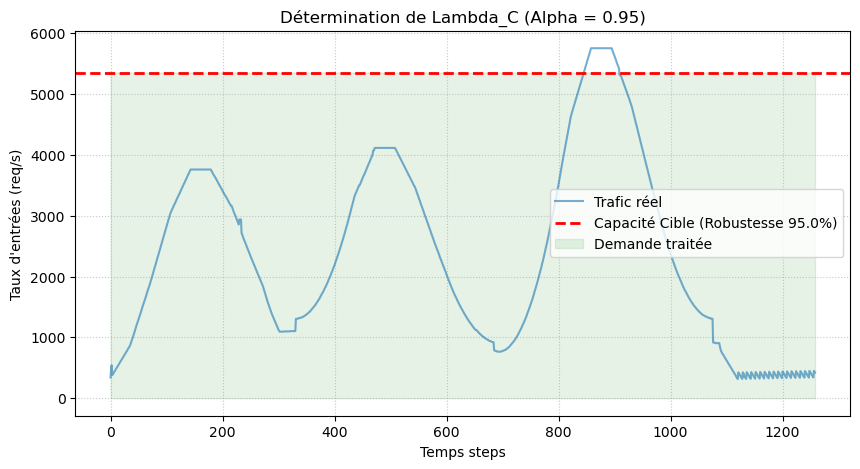

--- RÉSULTATS ÉTAPE 2 ---
**PIC DE TRAFIC MAXIMAL (Ymax)** : 5751.00 req/s
**CHARGE CIBLE RETENUE (Lambda_C)** : 5349.20 req/s
-> Ton infrastructure sera dimensionnée pour 5349.20 req/s.
-> Elle absorbera 95.0% des variations de charge.


In [20]:

# --- 1. Paramétrage de la Robustesse ---
alpha = 0.95  # Seuil de 95% (tu peux tester 0.90 ou 0.99)

# --- 2. Calcul de la Charge Cible (Lambda_C) ---
# On utilise y qui contient tes "input_rates"
lambda_c = np.percentile(y, alpha * 100)

# --- 3. Visualisation enrichie ---
plt.figure(figsize=(10, 5))
plt.plot(x, y, label="Trafic réel", alpha=0.6)

# On trace la ligne de la charge cible
plt.axhline(y=lambda_c, color='r', linestyle='--', linewidth=2, 
            label=f"Capacité Cible (Robustesse {alpha*100}%)")

# On colorie la zone "couverte" pour mieux voir
plt.fill_between(x, 0, lambda_c, color='green', alpha=0.1, label="Demande traitée")

plt.xlabel("Temps steps")
plt.ylabel("Taux d'entrées (req/s)")
plt.title(f"Détermination de Lambda_C (Alpha = {alpha})")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# --- 4. Affichage des résultats pour ton rapport ---
print(f"--- RÉSULTATS ÉTAPE 2 ---")
print(f"**PIC DE TRAFIC MAXIMAL (Ymax)** : {np.max(y):.2f} req/s")
print(f"**CHARGE CIBLE RETENUE (Lambda_C)** : {lambda_c:.2f} req/s")
print(f"-> Ton infrastructure sera dimensionnée pour {lambda_c:.2f} req/s.")
print(f"-> Elle absorbera {alpha*100}% des variations de charge.")